In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import sys
import os
import joblib  # For saving the final model

# Add project root to path
sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger
from src.models.optimization import optimize_xgboost
from src.utils.visualizations import plot_model_performance # Reusing this for before/after comparison

logger = setup_logger("04_model_tuning")

# Load Processed Data
data_path = "../data/processed/final_model_data.parquet"
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    logger.info(f"Data Loaded. Shape: {df.shape}")
else:
    logger.error("Data file not found. Run Notebook 02 first.")

2026-01-07 13:09:51,067 - INFO - Data Loaded. Shape: (93829, 93)


In [2]:
# Filter for recent regime (2023 onwards)
gdf = df.loc[df.index.get_level_values(0) >= pd.Timestamp('2023-01-01')].copy()

target_col = 'FwdRet'

# Separate features and target
X = gdf.drop(columns=[target_col])
y = gdf[target_col].copy()

# Clean NaNs (XGBoost handles them, but clean data is preferred for tuning)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print(f"Tuning Data Shape: X={X.shape}, y={y.shape}")

Tuning Data Shape: X=(8971, 92), y=(8971,)


In [3]:
# Run the Optimization
# This calls the logic from src/models/optimization.py
best_model, best_params, cv_results = optimize_xgboost(
    X, 
    y, 
    n_iter=20,      # Number of parameter combinations to try
    cv_splits=3     # Time-series splits
)

print("\n🏆 Best Parameters Found:")
for param, value in best_params.items():
    print(f"   - {param}: {value}")

2026-01-07 13:10:07,880 - INFO - Starting XGBoost optimization with 20 iterations...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
2026-01-07 13:10:18,719 - INFO - Optimization Complete. Best Score: -0.0418

🏆 Best Parameters Found:
   - subsample: 0.6
   - reg_lambda: 50
   - reg_alpha: 0
   - n_estimators: 100
   - max_depth: 6
   - learning_rate: 0.01
   - colsample_bytree: 0.6


2026-01-07 13:10:24,823 - INFO - Evaluating Baseline Model...
2026-01-07 13:10:26,035 - INFO - Evaluating Tuned Model...


,Model,R2 Mean,R2 Std
0,XGBoost (Baseline),0.047045,0.007439
1,XGBoost (Tuned),0.041433,0.004798


/Users/aengusmartindonaire/Downloads/systematic-equity-alpha/src/utils/visualizations.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


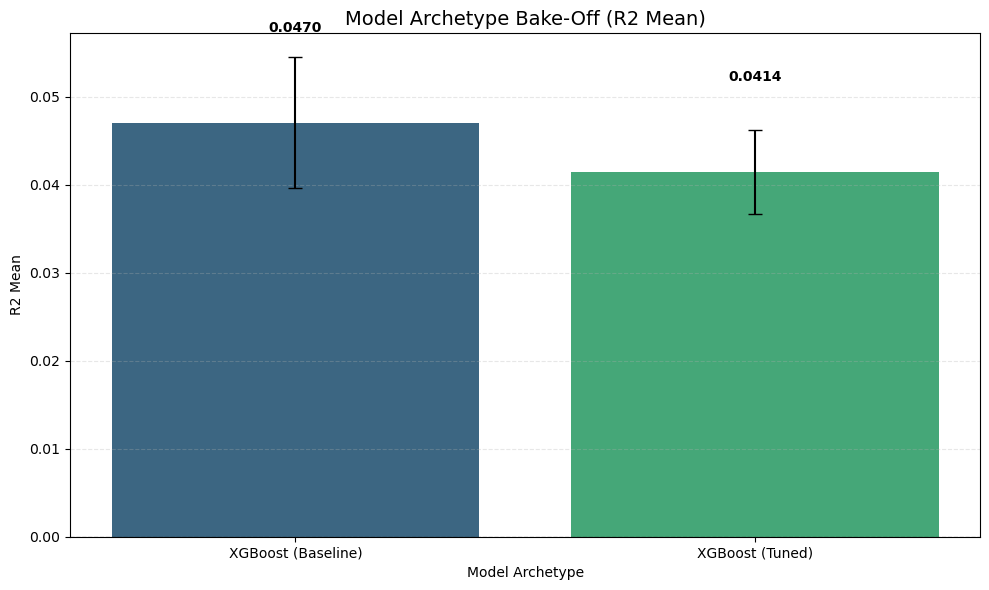

In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

# 1. Define Baseline (Notebook 03 Winner)
baseline_model = XGBRegressor(
    n_estimators=100,
    max_depth=4, 
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)

# 2. Evaluate Both models on the full set (5-Fold CV)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

logger.info("Evaluating Baseline Model...")
baseline_scores = cross_val_score(baseline_model, X, y, cv=cv, scoring='r2')

logger.info("Evaluating Tuned Model...")
tuned_scores = cross_val_score(best_model, X, y, cv=cv, scoring='r2')

# 3. Create Comparison DataFrame
comparison_df = pd.DataFrame([
    {'Model': 'XGBoost (Baseline)', 'R2 Mean': baseline_scores.mean(), 'R2 Std': baseline_scores.std()},
    {'Model': 'XGBoost (Tuned)',    'R2 Mean': tuned_scores.mean(),    'R2 Std': tuned_scores.std()}
])

display(comparison_df)

# Visualize
plot_model_performance(comparison_df, metric='R2 Mean', std_col='R2 Std')